# CodeAlpha Task 3 – Supermarket Sales Data Visualization


**Tools:** Python, Pandas, Matplotlib, Seaborn

### Objective
Create meaningful visualizations from supermarket sales data, identify trends/patterns, and communicate business insights.

### Visualizations
1. Category-wise Sales
2. Monthly Sales Trend
3. City-wise Sales
4. Payment Method Distribution
5. Category-wise Profit
6. Sales vs Profit
7. Quantity vs Sales
8. Correlation Heatmap
9. Monthly Sales & Profit comparison




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)+


## 1. Load the dataset

In [ ]:
df = pd.read_csv("supermarket_sales_intermediate.csv")
df["Date"] = pd.to_datetime(df["Date"])

df.head()


,Date,City,Category,Gender,Payment_Method,Quantity,Unit_Price,Sales,Profit
0,2025-01-02,Jabalpur,Electronics,Male,E-wallet,2,632.02,1264.04,141.08
1,2025-01-03,Indore,Electronics,Female,Card,1,1116.32,1116.32,219.86
2,2025-01-03,Jabalpur,Beauty,Male,UPI,2,369.10,738.20,87.12
3,2025-01-03,Bhopal,Sports,Female,E-wallet,3,540.03,1620.09,316.30
4,2025-01-04,Bhopal,Sports,Female,Card,7,528.16,3697.12,392.15


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.info()


Rows: 600
Columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            600 non-null    datetime64[ns]
 1   City            600 non-null    object        
 2   Category        600 non-null    object        
 3   Gender          600 non-null    object        
 4   Payment_Method  600 non-null    object        
 5   Quantity        600 non-null    int64         
 6   Unit_Price      600 non-null    float64       
 7   Sales           600 non-null    float64       
 8   Profit          600 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 42.3+ KB


In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
Date              0
City              0
Category          0
Gender            0
Payment_Method    0
Quantity          0
Unit_Price        0
Sales             0
Profit            0
dtype: int64

Duplicate rows: 0


## 2. Basic statistical overview

In [ ]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,600,NaN,NaN,NaN,2025-07-02 04:12:00,2025-01-02 00:00:00,2025-03-31 18:00:00,2025-06-30 12:00:00,2025-10-05 06:00:00,2025-12-31 00:00:00,NaN
City,600,5,Indore,128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,600,5,Clothing,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,600,2,Male,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment_Method,600,4,Card,193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,600.0,NaN,NaN,NaN,3.88,1.0,2.0,4.0,6.0,7.0,2.023798
Unit_Price,600.0,NaN,NaN,NaN,631.626217,230.97,459.07,612.515,762.095,1232.09,221.102976
Sales,600.0,NaN,NaN,NaN,2452.294,255.71,1190.785,2059.745,3461.9525,8428.0,1617.271855
Profit,600.0,NaN,NaN,NaN,366.744183,22.33,154.055,295.005,501.885,1600.03,280.136348


## 3. Feature Engineering

In [ ]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["Day"] = df["Date"].dt.day_name()

monthly = df.groupby("Month", as_index=False).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

category_summary = df.groupby("Category", as_index=False).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

city_summary = df.groupby("City", as_index=False).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

category_summary


,Category,Sales,Profit,Quantity
0,Beauty,134359.95,19932.01,366
1,Clothing,423359.45,65876.02,609
2,Electronics,460363.26,66313.56,527
3,Home & Kitchen,262940.80,38636.31,497
4,Sports,190352.94,29288.61,329


## 4. Category-wise Sales – Bar Chart

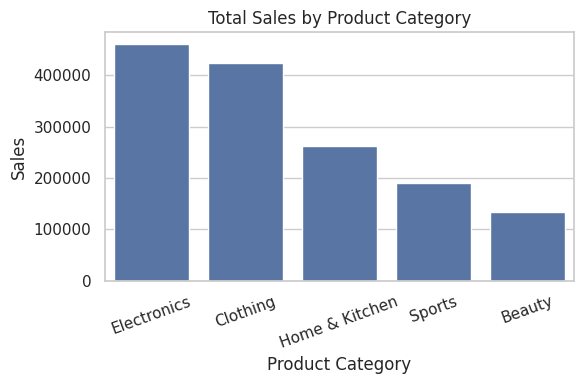

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data=category_summary.sort_values("Sales", ascending=False),
            x="Category", y="Sales")
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Insight:** Compare the categories by total sales and identify which product categories contribute most to revenue.

## 5. Monthly Sales Trend – Line Chart

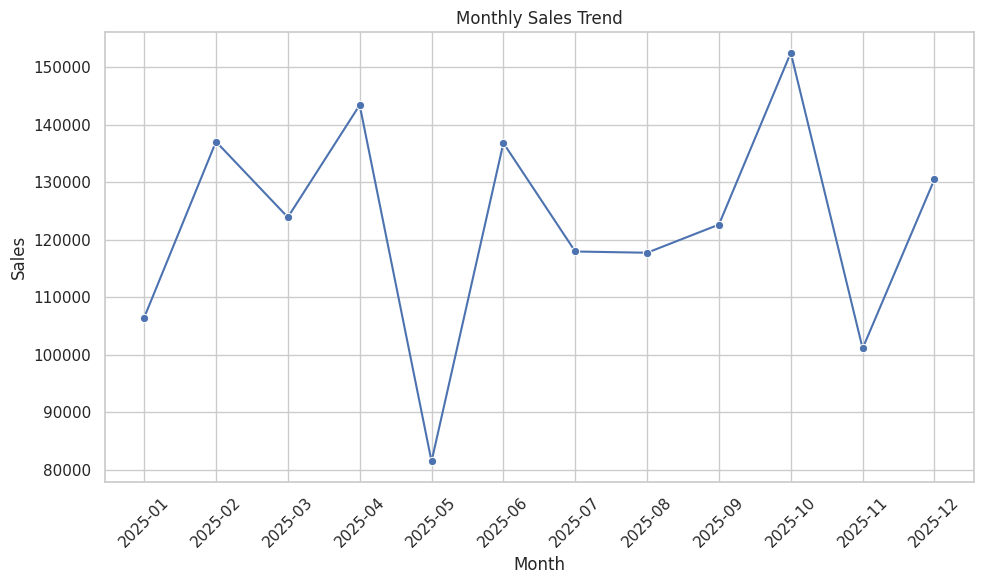

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data=monthly, x="Month", y="Sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** The line chart helps identify high-sales and low-sales months and whether revenue is increasing or decreasing over the year.

## 6. City-wise Sales – Horizontal Bar Chart

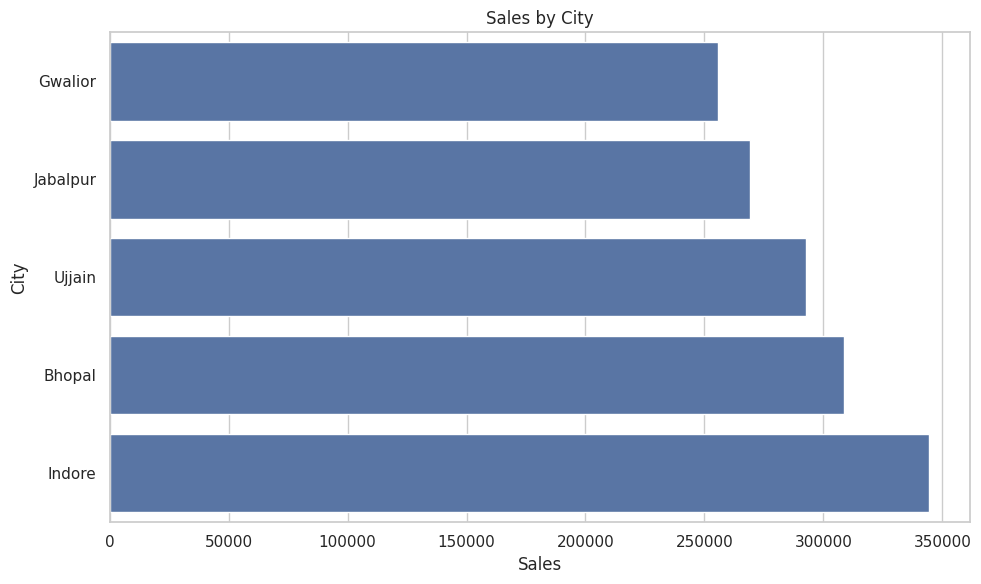

In [ ]:
city_sorted = city_summary.sort_values("Sales")

plt.figure(figsize=(10,6))
sns.barplot(data=city_sorted, x="Sales", y="City")
plt.title("Sales by City")
plt.xlabel("Sales")
plt.ylabel("City")
plt.tight_layout()
plt.show()


**Insight:** Compare city-level performance and identify locations contributing more revenue.

## 7. Payment Method Distribution – Pie Chart

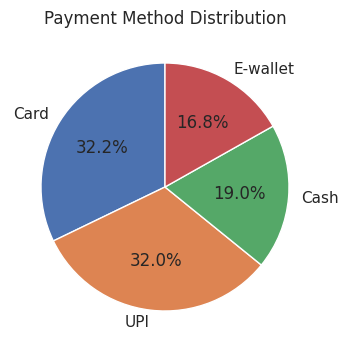

In [ ]:
payment_counts = df["Payment_Method"].value_counts()

plt.figure(figsize=(4,7))
plt.pie(payment_counts.values,
        labels=payment_counts.index,
        autopct="%1.1f%%",
        startangle=90)
plt.title("Payment Method Distribution")
plt.show()


**Insight:** The chart shows how customers prefer to pay for purchases.

## 8. Category-wise Profit – Bar Chart

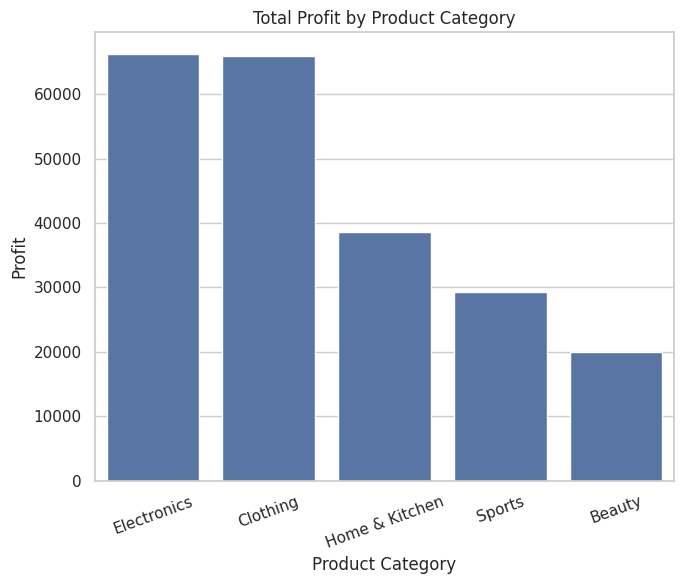

In [ ]:
plt.figure(figsize=(7,6))
sns.barplot(data=category_summary.sort_values("Profit", ascending=False),
            x="Category", y="Profit")
plt.title("Total Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Profit")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Insight:** A category can have high sales but comparatively lower profit, so sales and profit should be examined together.

## 9. Sales vs Profit – Scatter Plot

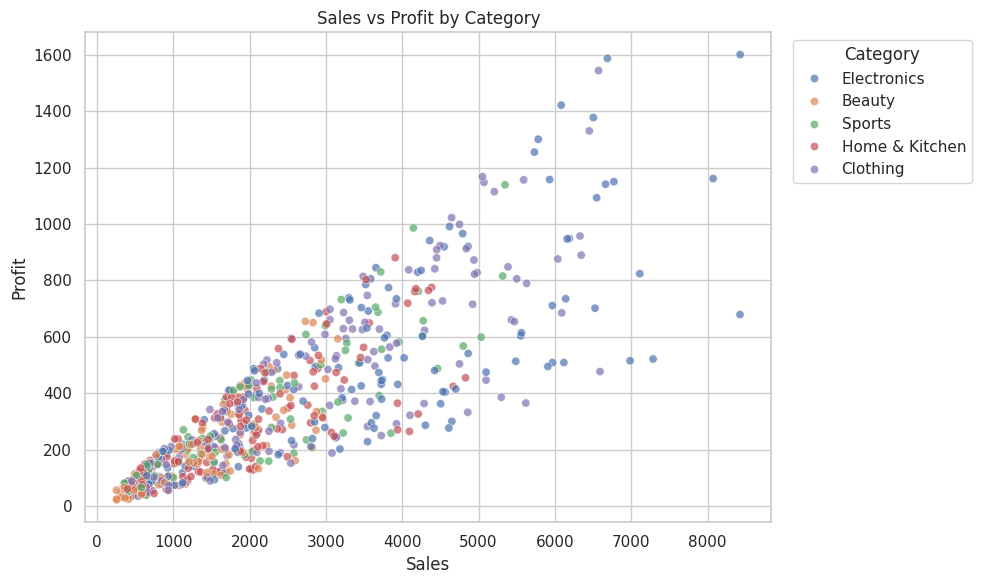

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Sales", y="Profit", hue="Category", alpha=0.7)
plt.title("Sales vs Profit by Category")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Insight:** The scatter plot helps examine whether higher sales values generally correspond to higher profit.

## 10. Quantity vs Sales – Scatter Plot

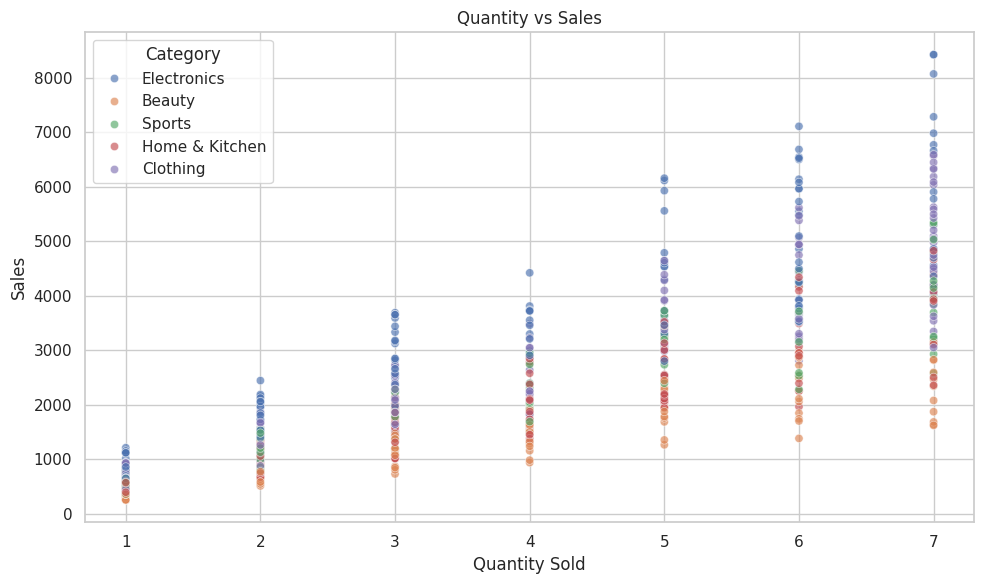

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Quantity", y="Sales", hue="Category", alpha=0.65)
plt.title("Quantity vs Sales")
plt.xlabel("Quantity Sold")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


**Insight:** This visualization shows how sales change with the number of units purchased.

## 11. Correlation Heatmap

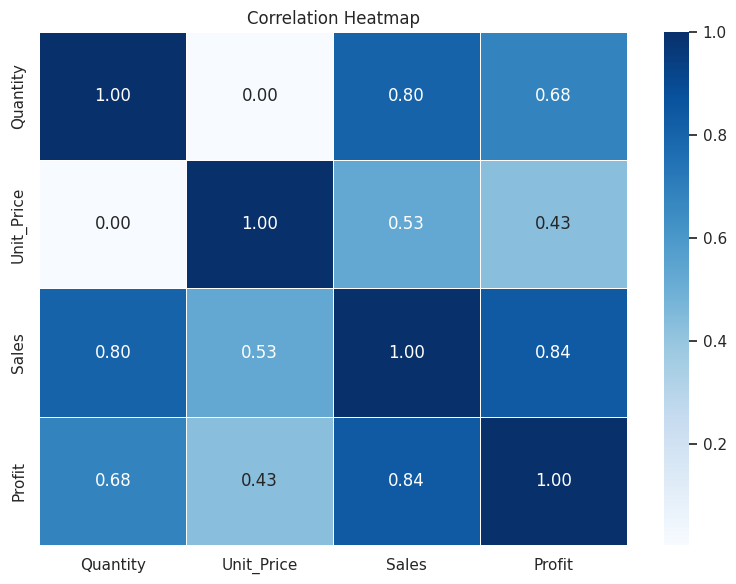

In [ ]:
numeric_cols = ["Quantity", "Unit_Price", "Sales", "Profit"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


**Insight:** Correlation values help identify relationships between numerical variables. Correlation does not by itself prove causation.

## 12. Monthly Sales vs Profit

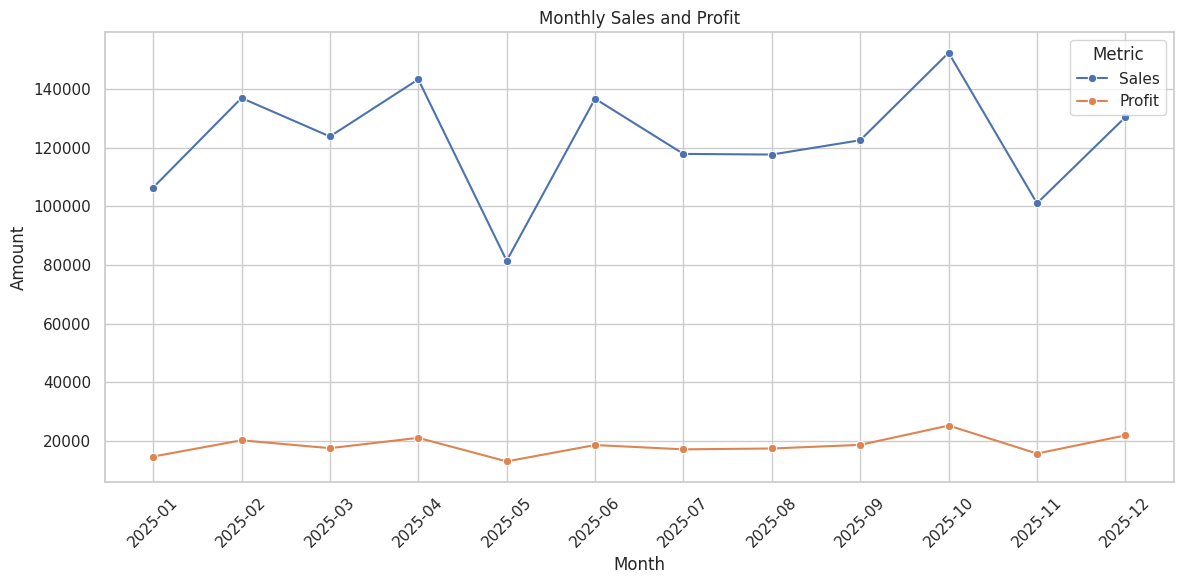

In [ ]:
monthly_long = monthly.melt(
    id_vars="Month",
    value_vars=["Sales", "Profit"],
    var_name="Metric",
    value_name="Amount"
)

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_long, x="Month", y="Amount",
             hue="Metric", marker="o")
plt.title("Monthly Sales and Profit")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 13. Key Business Insights

1. Electronics generated the highest sales.
2. Indore generated the highest sales among all cities.
3. Electronics generated the highest profit.
4. October recorded the highest monthly sales.
5. Card was the most frequently used payment method.
6. Sales and Profit showed a strong positive relationship.

